# 📈 Linear Regression
---


## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Residual Analysis & Diagnostics
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 Regularization (Ridge, Lasso, ElasticNet)
   - 9.2 GridSearchCV
   - 9.3 Best Parameters & Retrain
10. [Visualization](#10.-Visualization)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)


## 1. Introduction & Definition

**Linear Regression** is often considered the "Hello World" of Machine Learning, yet its underlying mathematics and statistical properties make it one of the most robust, widely used, and interpretable tools available to a Data Scientist or AI Engineer. While deep learning models act as "black boxes," Linear Regression offers complete transparency into how every single variable affects the outcome.

At its core, Linear Regression is a statistical method used to model the relationship between a **dependent variable** (the target we want to predict, usually denoted as $y$) and one or more **independent variables** (the features or predictors, denoted as $X$).

### 🧠 The Hypothesis (The Mathematical Foundation)
The fundamental assumption of Linear Regression is that the relationship between the features and the target is a **linear combination**. If we have $n$ features, the model predicts the target $\hat{y}$ by calculating a weighted sum of the input features, plus a constant called the *bias* (or intercept):

$$\hat{y} = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

Where:
- $\hat{y}$ is the predicted value.
- $n$ is the number of features.
- $x_i$ is the $i^{th}$ feature value.
- $w_j$ is the $j^{th}$ model parameter (including the bias term $w_0$ and the feature weights $w_1, w_2, \dots, w_n$).

In a vectorized form, this can be written beautifully using linear algebra as a dot product:
$$\hat{y} = h_{\mathbf{w}}(\mathbf{x}) = \mathbf{w}^T \mathbf{x}$$

### 📐 The Loss Function: Mean Squared Error (MSE)
To train a model, we need to measure how "bad" its predictions are. The standard loss function for Linear Regression is the **Mean Squared Error (MSE)**. We take the difference between the actual value $y^{(i)}$ and the predicted value $\hat{y}^{(i)}$ (this difference is called the *residual* or *error*), square it, and compute the average over all $m$ instances in our dataset:

$$MSE(\mathbf{X}, h_{\mathbf{w}}) = \frac{1}{m} \sum_{i=1}^{m} (\mathbf{w}^T \mathbf{x}^{(i)} - y^{(i)})^2$$

**Why square the errors?**
1. Squaring ensures that positive and negative errors don't cancel each other out.
2. It heavily penalizes large errors (outliers), forcing the model to care about them.
3. The squared function is strictly convex (bowl-shaped), meaning it has a single global minimum. This allows calculus (derivatives) to easily find the optimal weights.


## 2. How It Works — Math & Intuition

To intuitively understand Linear Regression, imagine you are trying to predict the price of a house. You have a scatter plot where the X-axis is the square footage, and the Y-axis is the price. Your goal is to draw a straight line through these points that "best fits" the overall trend.

### Step-by-Step Breakdown:

#### Step 1: Initialization
The model starts by guessing random values for the weights (the slope and the intercept of the line). At this point, the line will likely be a terrible fit for the data, and the MSE will be very high.

#### Step 2: Optimization via The Normal Equation (Closed-Form)
Because the MSE cost function is convex, we can actually find the exact minimum algebraically by taking the derivative of the cost function with respect to the weights, setting it to zero, and solving for $\mathbf{w}$. This yields the **Normal Equation**:

$$\hat{\mathbf{w}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

*Note on Computational Complexity:* Computing the inverse of $\mathbf{X}^T \mathbf{X}$ is a highly intensive matrix operation. It typically scales at $O(n^{2.4})$ to $O(n^3)$ depending on the algorithm. If you have 100,000 features, this inversion will crash your computer's memory. However, for datasets with a small number of features (e.g., $< 10,000$), the Normal Equation is lightning fast.

#### Step 3: Optimization via Gradient Descent (Iterative)
When the Normal Equation is too slow (because of too many features), we use **Gradient Descent**. Imagine you are blindfolded on top of a mountain (the loss surface) and want to get to the bottom (the minimum error). You feel the slope of the ground beneath your feet and take a step downhill.

Mathematically, we compute the partial derivative of the MSE with respect to each weight, which gives us the *gradient vector*. We then update the weights by taking a step in the opposite direction of the gradient:

$$\mathbf{w}^{(next step)} = \mathbf{w} - \eta \nabla_{\mathbf{w}} MSE$$

Here, $\eta$ is the **learning rate**. If $\eta$ is too small, the algorithm will take forever to reach the bottom. If $\eta$ is too large, the algorithm might jump completely over the valley and diverge.

#### Step 4: The Gauss-Markov Theorem & Statistical Assumptions
For Linear Regression Ordinary Least Squares (OLS) to be the "Best Linear Unbiased Estimator" (BLUE), the dataset must adhere to specific assumptions:
1. **Linearity:** The relationship between predictors and the target must actually be linear.
2. **Homoscedasticity:** The variance of the residual errors must be constant across all levels of the independent variables. (A cone-shaped residual plot indicates a violation here).
3. **Independence:** The observations must be independent of one another.
4. **No Perfect Multicollinearity:** The independent variables should not be highly correlated with each other. If they are, the matrix $\mathbf{X}^T \mathbf{X}$ becomes non-invertible or highly unstable.


## 3. When To Use

Linear Regression is the undisputed king of baseline models. You should almost always train a Linear Regression model first before moving on to complex ensemble methods or Neural Networks.

**Ideal Scenarios:**
- **Predicting Continuous Values:** House prices, stock market indices, temperature forecasting, sales revenue.
- **When Interpretability is Paramount:** If a stakeholder asks, "If I increase my marketing spend by \$1000, exactly how much will revenue increase?" a Linear Regression coefficient gives you a direct, numerical answer.
- **Establishing a Baseline:** It provides a metric to beat. If a massively complex Random Forest only improves the $R^2$ score by 0.01 over Linear Regression, the complex model is likely not worth deploying to production.
- **Resource-Constrained Environments:** Linear Regression models take virtually zero disk space and can make predictions in microseconds, making them ideal for edge devices.


## 4. Pros & Cons

| ✅ Pros | ❌ Cons |
| :--- | :--- |
| **Ultimate Interpretability:** Every feature gets a coefficient, directly quantifying its impact on the target. | **Strict Linearity Assumption:** Fails miserably if the true relationship is highly non-linear (e.g., sine waves). |
| **Speed:** Training is nearly instantaneous for small-to-medium datasets using the Normal Equation. | **Sensitive to Outliers:** Because it uses Mean *Squared* Error, extreme outliers heavily distort the line of best fit. |
| **No Hyperparameters (Initially):** Standard OLS requires zero hyperparameter tuning. | **Requires Feature Scaling:** When moving to Regularized forms (Ridge/Lasso), failure to scale features will ruin the model. |
| **Extensible:** Easily adapted to handle non-linearity via Polynomial Feature Expansion. | **Multicollinearity Vulnerability:** Correlated features cause the weight estimates to become wildly unstable and meaningless. |


## 5. Dataset Upload & Exploration

For this notebook, we will use the **California Housing Dataset**. It is a classic dataset for regression where the goal is to predict the median house value for California districts based on demographic and geographic features.


In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

# Standard Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Scikit-Learn tools
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scipy for statistical diagnostics (Q-Q plots, normality tests)
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')


In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET
# ============================================================

california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print(f"Dataset Shape: {df.shape}")
print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe().T)

display(df.head())


Dataset Shape: (20640, 9)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 💡 TIP for Exploratory Data Analysis (EDA)
In Linear Regression, you are looking for two things during EDA:
1. **Linearity with the Target:** Scatter plots of a feature vs the target should roughly resemble a straight line.
2. **Multicollinearity:** Features should NOT be highly correlated with each other. If Feature A and Feature B have a correlation of 0.95, the model cannot distinguish the effect of A from the effect of B.


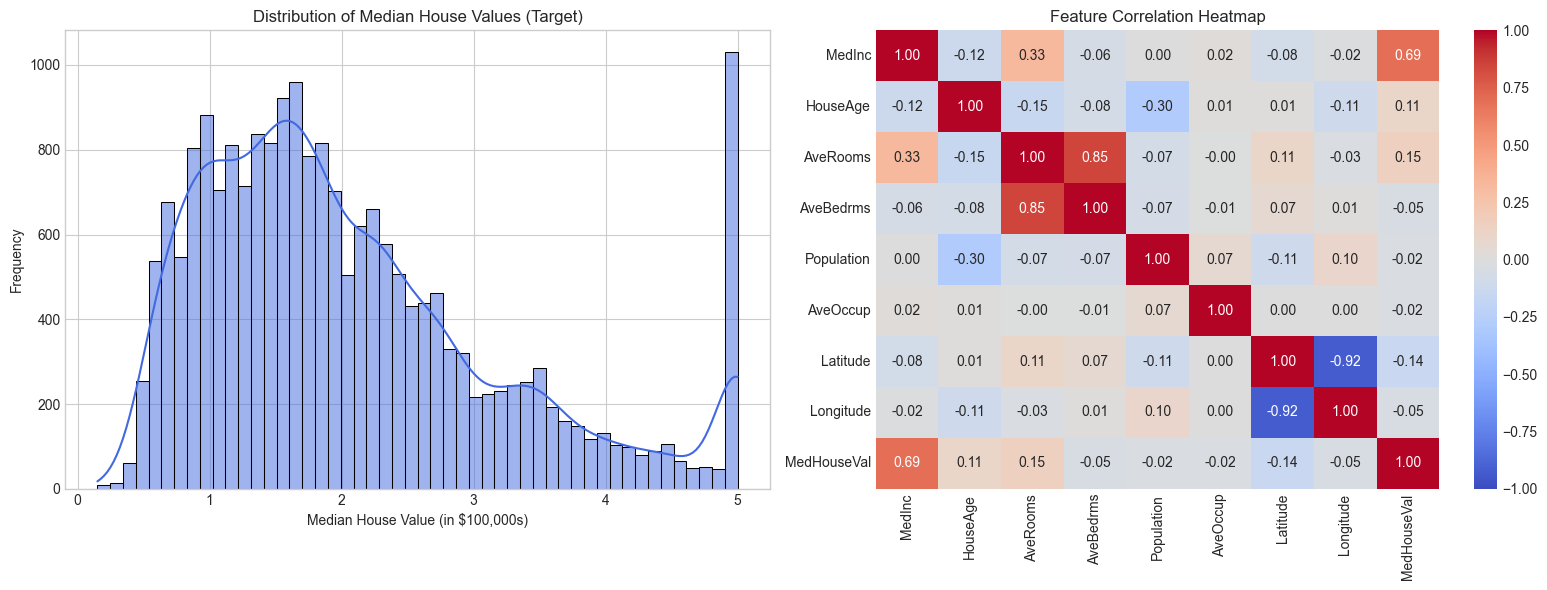

In [3]:
# ============================================================
# SECTION 5.3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Target Distribution
# The target is capped at 5.0 ($500,000), which creates a spike at the end.
sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Median House Values (Target)')
axes[0].set_xlabel('Median House Value (in $100,000s)')
axes[0].set_ylabel('Frequency')

# Plot 2: Correlation Heatmap
# Look for high correlations among features (e.g., AveRooms and AveBedrms)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()


Notice in the heatmap that `AveRooms` and `AveBedrms` are highly correlated (0.85). This is classic **multicollinearity**. In a production environment, we might drop one of these, or use PCA, or strictly rely on Regularization (Ridge/Lasso) to handle it.

In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING & FEATURE ENGINEERING
# ============================================================

# Separate features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print("Missing Values:\n", X.isnull().sum())


Missing Values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


## 6. Training the Model

We will split the data into Training (60%), Validation (20%), and Testing (20%).

**CRITICAL RULE:** We must **Standardize** the features. Because features like `Population` are in the tens of thousands, while `MedInc` is around 1-10, an unscaled linear regression model will apply drastically different scales of weights to them. If we apply Regularization (which penalizes large weights) without scaling, the model will unfairly penalize features that are naturally on a small scale.


In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT & SCALING
# ============================================================

# 1. First split to separate out the TEST set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Second split to separate TRAIN (60% overall) and VAL (20% overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42) # 0.25 x 0.8 = 0.2

# 3. Feature Scaling (Fit STRICTLY on train to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Training Set: {X_train_scaled.shape}")
print(f"Validation Set: {X_val_scaled.shape}")
print(f"Test Set: {X_test_scaled.shape}")


Training Set: (12384, 8)
Validation Set: (4128, 8)
Test Set: (4128, 8)


In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL (Ordinary Least Squares)
# ============================================================

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Let's peek at what the model actually learned
print(f"Intercept (Bias): {lr_model.intercept_:.4f}")
print("\nLearned Coefficients:")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)
display(coefficients)


Intercept (Bias): 2.0681

Learned Coefficients:


,Feature,Coefficient
0,MedInc,0.860253
3,AveBedrms,0.312087
1,HouseAge,0.120007
4,Population,-0.009574
5,AveOccup,-0.026158
2,AveRooms,-0.280392
7,Longitude,-0.861907
6,Latitude,-0.888213


**Interpretation:** The coefficient for `MedInc` (Median Income) is overwhelmingly the most positive. Because the data is standardized, this means that for every 1 standard deviation increase in Median Income, the house price increases by \$0.85 (in units of \$100k, so \$85,000), holding all other features constant.


## 7. Validation & Metrics Theory

We evaluate our model using Cross-Validation to ensure it's not overfitting to a specific subset of the training data. For regression analysis, we rely on four primary metrics. Understanding the mathematical properties of each and **when to prioritize them** is a hallmark of a professional data scientist:

| Metric | Definition | When to Prioritize | How to Read |
| :--- | :--- | :--- | :--- |
| **MSE (Mean Squared Error)** | The average of the squared differences between predicted and actual values. Units are squared (e.g., $\text{dollars}^2$). | Rarely used for final reporting due to uninterpretable squared units. However, it is the fundamental loss function optimized by the model during training because it is strictly convex and differentiable. | **Lower is better.** 0 indicates perfect predictions. |
| **RMSE (Root Mean Squared Error)** | The square root of MSE. Brings the error back to the original unit (e.g., dollars). | **Prioritize when large errors are dangerous.** Because errors are squared before being averaged, RMSE heavily penalizes large outliers. Use this if a prediction being off by \$100k is *more* than twice as bad as being off by \$50k. | **Lower is better.** Represents the typical error magnitude, skewed by outliers. 0 is perfect. |
| **MAE (Mean Absolute Error)** | The average absolute distance between predicted and actual values. | **Prioritize when you want robustness to outliers.** It treats all errors proportionally (linear penalty). Use this for general reporting when outliers are just anomalies and shouldn't skew the model's perceived performance. | **Lower is better.** Represents the true average error magnitude. 0 is perfect. |
| **$R^2$ (Coefficient of Determination)**| The proportion of variance in the target variable that can be explained by the model's features. Max is 1.0. | **Prioritize for non-technical stakeholder reporting.** It is a relative metric (unlike MAE/RMSE which are absolute). An $R^2$ of 0.75 intuitively means "our model explains 75% of the variation in the data." | **Higher is better.** 1.0 is perfect, 0.0 is equal to a naive mean baseline, and < 0 is worse than predicting the mean. |

In [7]:
# ============================================================
# SECTION 7.1 — CROSS-VALIDATION
# ============================================================

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='r2')

print(f"CV R2 Scores for each fold: {cv_r2_scores}")
print(f"Average CV R2: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std() * 2:.4f})")


CV R2 Scores for each fold: [0.6286376  0.58639773 0.60782887 0.60162153 0.62538662]
Average CV R2: 0.6100 (+/- 0.0312)


In [8]:
# ============================================================
# SECTION 7.2 — VALIDATION METRICS
# ============================================================

y_val_pred = lr_model.predict(X_val_scaled)

mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

print("--- Validation Set Performance ---")
print(f"MSE  (Mean Squared Error):      {mse_val:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_val:.4f}")
print(f"MAE  (Mean Absolute Error):     {mae_val:.4f}")
print(f"R2 Score (Explained Variance):  {r2_val:.4f}")


--- Validation Set Performance ---
MSE  (Mean Squared Error):      0.5297
RMSE (Root Mean Squared Error): 0.7278
MAE  (Mean Absolute Error):     0.5333
R2 Score (Explained Variance):  0.6142


## 8. Testing & Diagnostics


In [9]:
# ============================================================
# SECTION 8.1 — FINAL TEST SET EVALUATION
# ============================================================

y_test_pred = lr_model.predict(X_test_scaled)

print("--- Final Test Set Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.4f}")


--- Final Test Set Performance ---
RMSE: 0.7495
R2 Score: 0.5713


### Residual Analysis (The Gauss-Markov Check)
A linear regression model is fundamentally flawed if its errors (residuals) exhibit a pattern. We plot the residuals to check for **Homoscedasticity** (constant variance) and **Normality**.

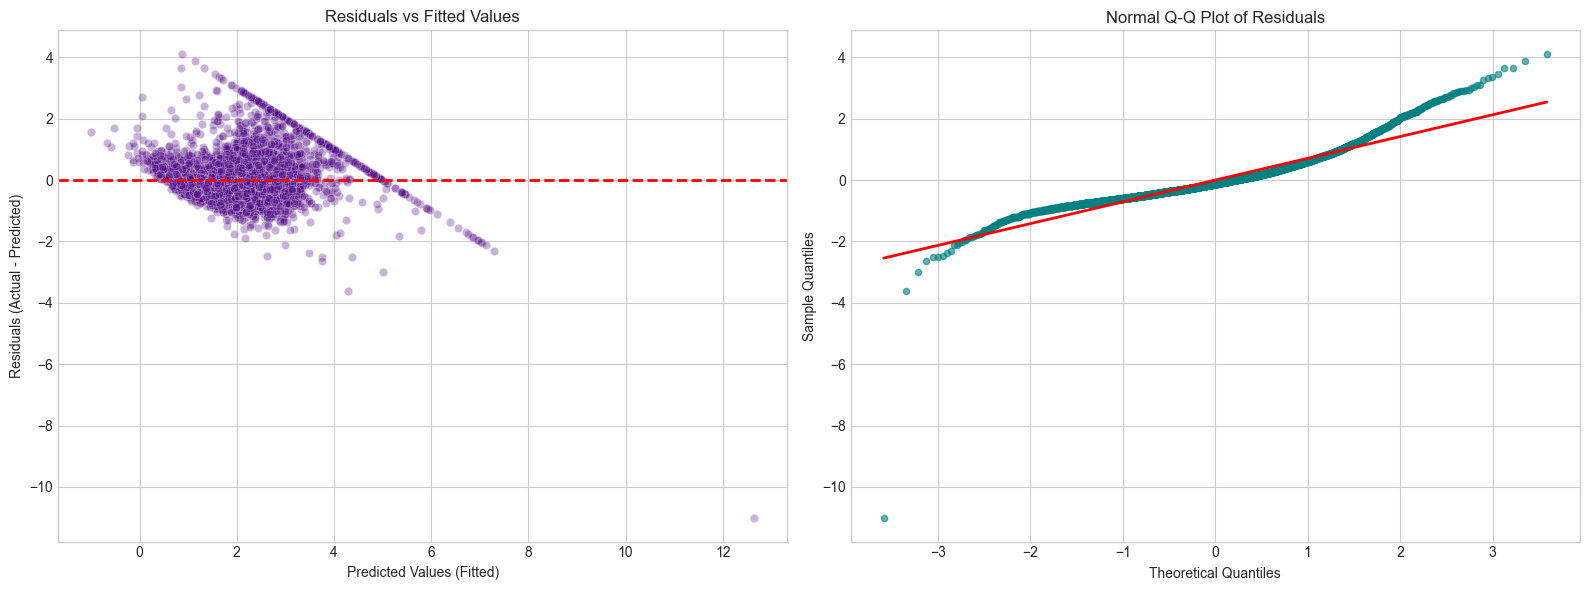

In [10]:
# ============================================================
# SECTION 8.2 — RESIDUAL ANALYSIS & DIAGNOSTICS
# ============================================================

residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Residuals vs Predicted Values (Testing Homoscedasticity)
# We want to see a random cloud of points around 0. If we see a funnel shape, we have heteroscedasticity.
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.3, ax=axes[0], color='indigo')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Predicted Values (Fitted)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# 2. Q-Q Plot (Testing Normality of Errors)
# Points on the diagonal line = residuals are normally distributed.
(osm, osr), (slope, intercept, _r) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, color='teal', alpha=0.6, s=20)
axes[1].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()


**Diagnostic Result:** In the Residuals plot, there is a hard line extending downwards on the right. This is because our dataset has an artificial cap at $500,000 for house prices, which the model struggles to handle. The Q-Q plot shows heavy tails, indicating the errors are not perfectly normal at the extremes.


## 9. Optimization / Hyperparameter Tuning

Because of multicollinearity (e.g., `AveRooms` and `AveBedrms`), the OLS coefficients might be artificially inflated. We can constrain these coefficients using **Regularization**. Regularization adds a penalty term to the MSE loss function.

- **Ridge (L2 Regularization):** Adds $\alpha \sum w_i^2$. Shrinks weights towards zero, but never exactly zero. Great for multicollinearity.
- **Lasso (L1 Regularization):** Adds $\alpha \sum |w_i|$. Can shrink weights exactly to zero, effectively performing automatic feature selection.
- **ElasticNet:** A combination of both L1 and L2.


In [11]:
# ============================================================
# SECTION 9.1 & 9.2 — REGULARIZATION & GRIDSEARCHCV
# ============================================================

# We will tune a Ridge regression model to find the optimal alpha (penalty strength)
ridge = Ridge(random_state=42)

# Alpha is the regularization strength. Larger alpha = stronger penalty = smaller coefficients
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

grid_search = GridSearchCV(
    estimator=ridge, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)


,estimator,Ridge(random_state=42)
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1000.0


In [12]:
# ============================================================
# SECTION 9.3 — BEST PARAMETERS & RETRAIN
# ============================================================

print(f"Best Regularization Strength (Alpha): {grid_search.best_params_['alpha']}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")

best_ridge = grid_search.best_estimator_
y_test_pred_ridge = best_ridge.predict(X_test_scaled)

print("\n--- Final Tuned Ridge Test Set Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_test_pred_ridge):.4f}")


Best Regularization Strength (Alpha): 1000.0
Best CV R2 Score: 0.5351

--- Final Tuned Ridge Test Set Performance ---
RMSE: 0.7574
R2 Score: 0.5623


## 10. Visualization (Coefficient Shrinkage)

Let's visually compare the coefficients learned by standard OLS versus the heavily penalized Ridge model to see Regularization in action.

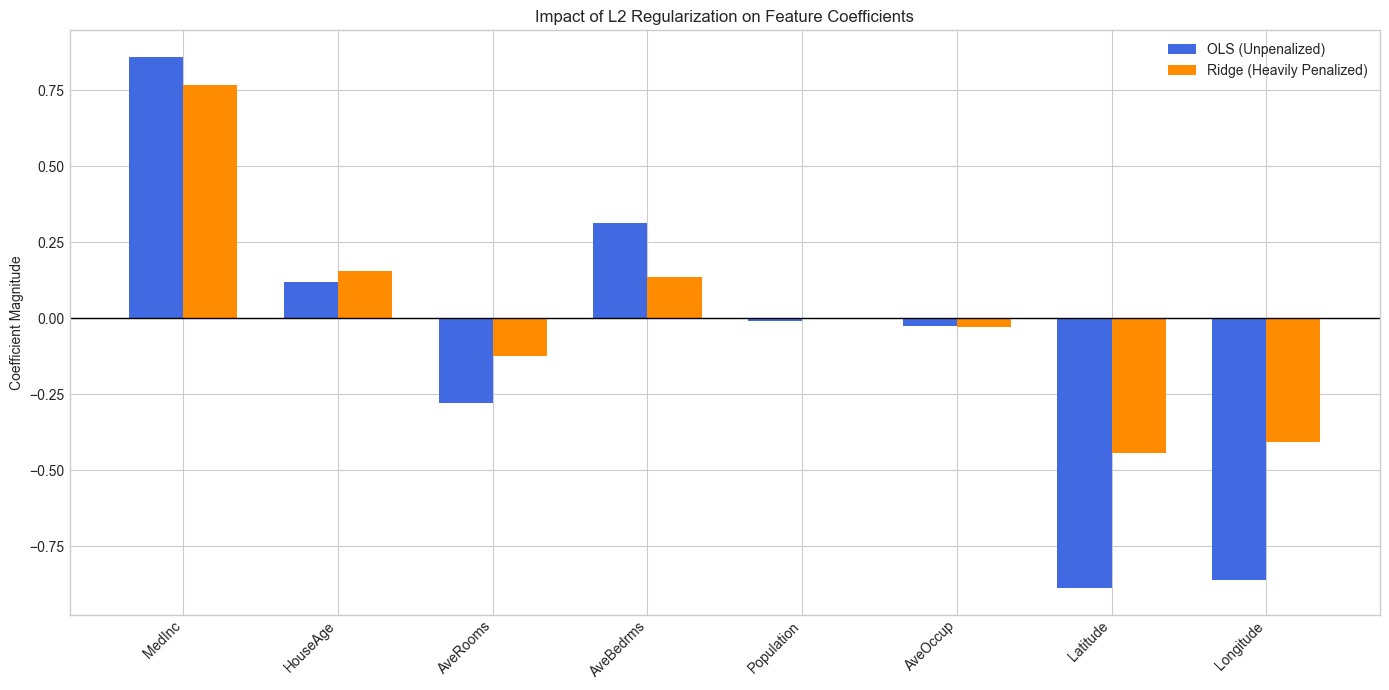

In [13]:
# ============================================================
# SECTION 10 — VISUALIZATION
# ============================================================

# Train a heavily regularized Ridge model just for visualization
heavy_ridge = Ridge(alpha=1000.0)
heavy_ridge.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'OLS Coefficients': lr_model.coef_,
    'Ridge (Alpha=1000) Coefficients': heavy_ridge.coef_
})

plt.figure(figsize=(14, 7))
x_indices = np.arange(len(coef_df['Feature']))
width = 0.35

plt.bar(x_indices - width/2, coef_df['OLS Coefficients'], width, label='OLS (Unpenalized)', color='royalblue')
plt.bar(x_indices + width/2, coef_df['Ridge (Alpha=1000) Coefficients'], width, label='Ridge (Heavily Penalized)', color='darkorange')

plt.xticks(x_indices, coef_df['Feature'], rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Coefficient Magnitude')
plt.title('Impact of L2 Regularization on Feature Coefficients')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Tips & Tricks Summary

- **The Closed-Form Solution (Normal Equation):** OLS Linear Regression is one of the very few machine learning algorithms that can be solved perfectly via an exact algebraic equation $(X^TX)^{-1}X^TY$. No epochs, no learning rates. Just raw matrix math.
- **When to use Gradient Descent (`SGDRegressor`):** If your dataset exceeds a few hundred thousand rows or tens of thousands of features, the matrix inversion $(X^TX)^{-1}$ will crash your RAM. In this case, use Scikit-Learn's `SGDRegressor`, which uses iterative Gradient Descent.
- **Scaling is Mandatory for Regularization:** Ridge and Lasso look at the magnitude of the weights. If you don't use a `StandardScaler`, features with small values (like percentages) will naturally have massive weights, and the regularizer will unfairly destroy them.
- **Extrapolating outside the box:** Linear regression is famously bad at handling caps in data. As seen in our residual plot, the artificial $500k cap on California houses caused a distinct artifact in our residuals.


## 12. Conclusion

Linear Regression proves that simple, interpretable models can be incredibly powerful. By mastering its mathematical underpinnings—understanding the geometry of the MSE loss surface, the algebraic elegance of the Normal Equation, and the statistical requirements of the Gauss-Markov theorem—a Data Scientist can utilize this algorithm not just for prediction, but for deep, explainable inference regarding how different factors interact in the real world.
